# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

In [1]:
import warnings
warnings.filterwarnings('ignore')

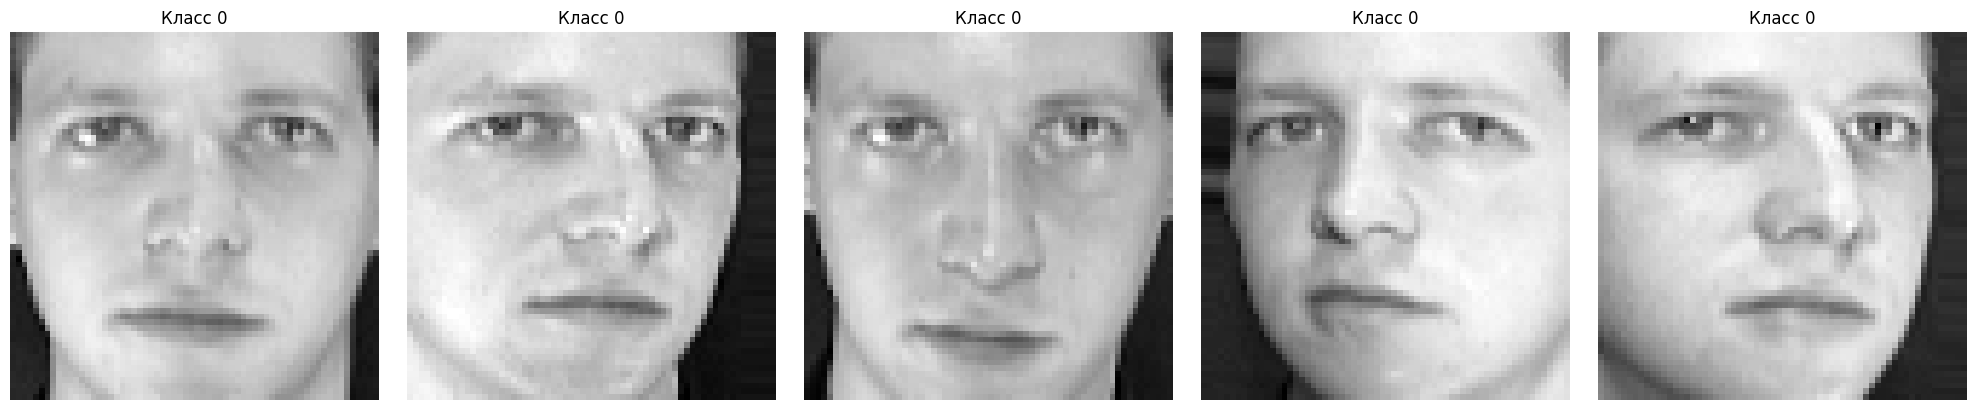

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [4]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [5]:
# Импортируем всякое
import time
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
# GradientBoostingClassifier
start_time = time.time()
gbc = GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)
training_time_gbc = time.time() - start_time
y_pred_gbc = gbc.predict(X_test)
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)


In [7]:
# XGBoost
start_time = time.time()
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {'objective': 'multi:softmax', 'num_class':40, 'eval_metric': 'logloss', 'eta': 0.1, 'max_depth': 3}
num_rounds = 100
bst_xgb = xgb.train(params, dtrain, num_rounds)
training_time_xgb = time.time() - start_time
y_pred_xgb = bst_xgb.predict(dtest).astype(int)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

In [8]:
# LightGBM
start_time = time.time()
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
params = {'objective': 'multiclass', 'num_class':40, 'metric': 'multi_logloss', 'learning_rate': 0.1, 'num_leaves': 31, 'verbose': -1}
num_round = 100
bst_lgb = lgb.train(params, train_data, num_round, valid_sets=[test_data])
training_time_lgb = time.time() - start_time
y_pred_lgb = np.argmax((bst_lgb.predict(X_test, num_iteration=bst_lgb.best_iteration) > 0.5).astype(int), axis=1)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)

In [9]:
# CatBoost
start_time = time.time()
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)
model_cb = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
model_cb.fit(train_pool)
training_time_cb = time.time() - start_time
y_pred_cb = model_cb.predict(test_pool)
accuracy_cb = accuracy_score(y_test, y_pred_cb)

In [10]:
print(f'Accuracy of GradientBoostingClassifier is {accuracy_score(y_test, y_pred_gbc)}') # Accuracy GradientBoostingClassifier
print(f'Accuracy of XGBoost is {accuracy_score(y_test, y_pred_xgb)}') # Accuracy XGBoost
print(f'Accuracy of LightGBM is {accuracy_score(y_test, y_pred_lgb)}') # Accuracy LightGBM
print(f'Accuracy of CatBoost is {accuracy_score(y_test, y_pred_cb)}') # Accuracy CatBoost

Accuracy of GradientBoostingClassifier is 0.4625
Accuracy of XGBoost is 0.7125
Accuracy of LightGBM is 0.725
Accuracy of CatBoost is 0.9375


CatBoost является самым крутым

In [11]:
print("GradientBoostingClassifier")
print(classification_report(y_test, y_pred_gbc))
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("LightGBM")
print(classification_report(y_test, y_pred_lgb))
print("CatBoost")
print(classification_report(y_test, y_pred_cb))

GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      1.00      1.00         1
           2       0.33      0.50      0.40         2
           3       0.00      0.00      0.00         4
           4       0.50      0.67      0.57         3
           5       1.00      0.33      0.50         3
           7       1.00      0.50      0.67         6
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         2
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.67      0.67      0.67         3
          15       0.50      0.50      0.50         2
          17       0.00      0.00      0.00         3
          18       1.00      1.00      1.00         1


In [12]:
# Функция составления матрицы ошибок
def conf_matr(y_test, pred, title):
  cm = confusion_matrix(y_test, pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title(title)
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()

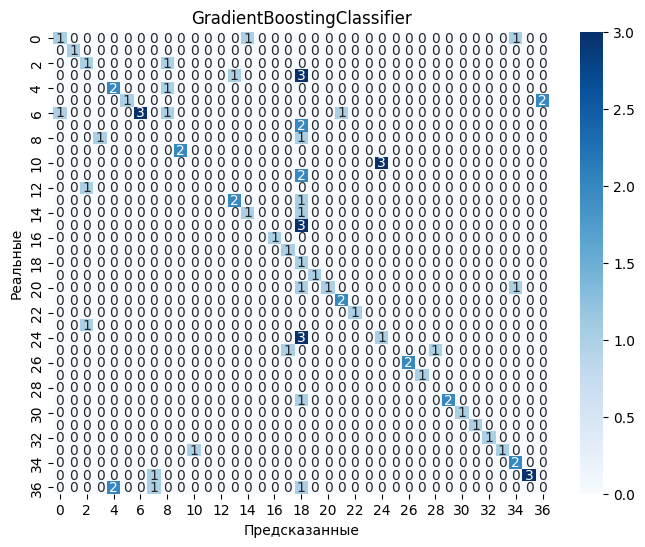

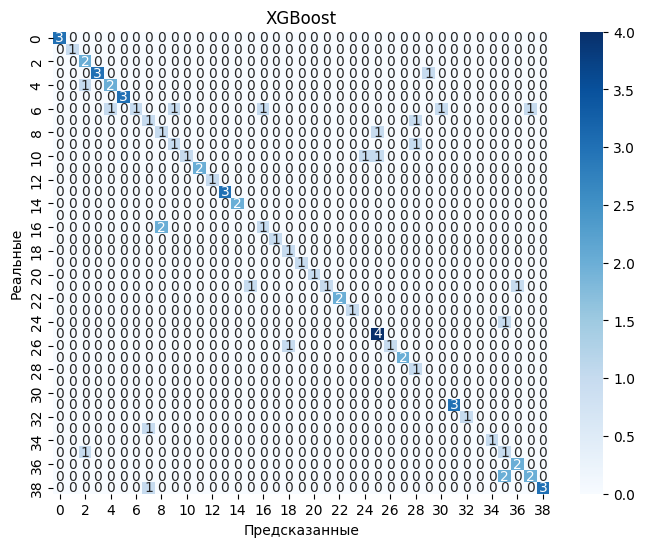

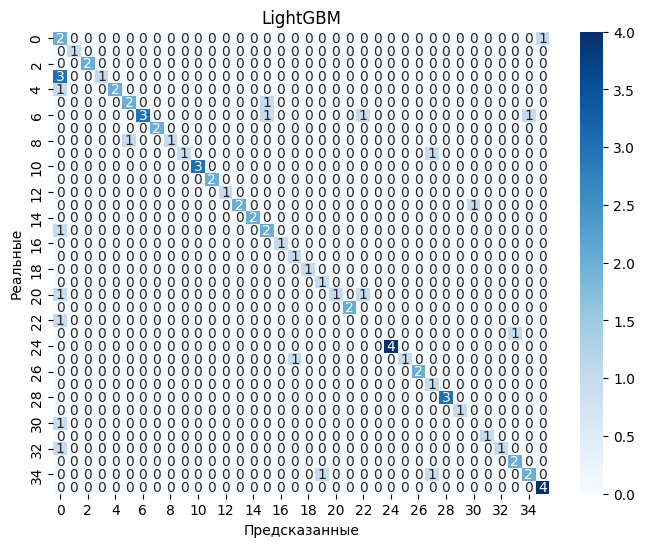

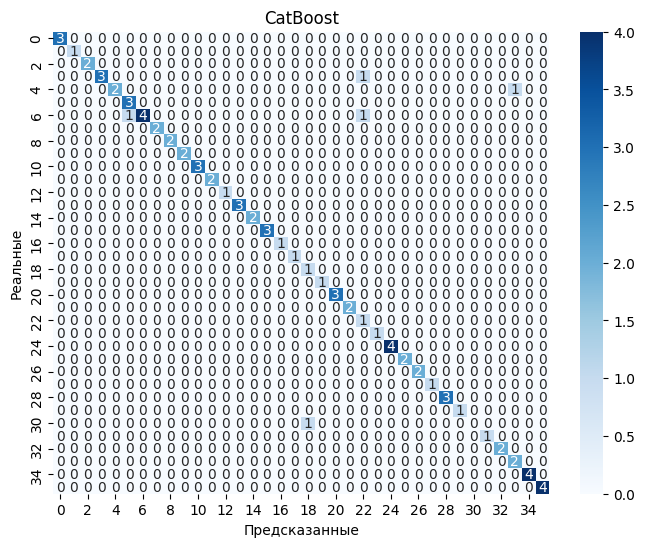

In [13]:
conf_matr(y_test, y_pred_gbc, "GradientBoostingClassifier")
conf_matr(y_test, y_pred_xgb, "XGBoost")
conf_matr(y_test, y_pred_lgb, "LightGBM")
conf_matr(y_test, y_pred_cb, "CatBoost")

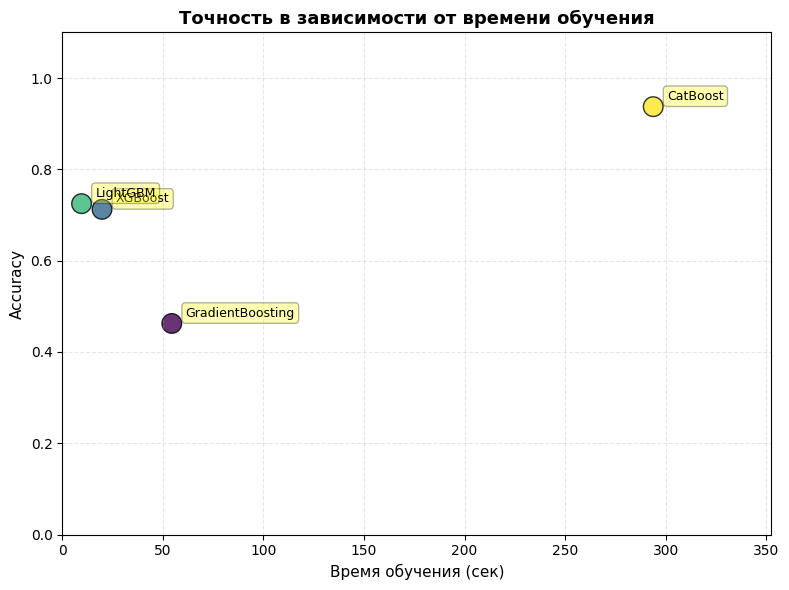

In [14]:
models = ['GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
accuracies = [accuracy_gbc, accuracy_xgb, accuracy_lgb, accuracy_cb]
training_times = [training_time_gbc, training_time_xgb, training_time_lgb, training_time_cb]
fig2, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(training_times, accuracies, s=200, c=range(len(models)), 
                     cmap='viridis', edgecolors='black', alpha=0.8)

# Подписываем точки
for i, (model, time, acc) in enumerate(zip(models, training_times, accuracies)):
    ax.annotate(model, (time, acc), xytext=(10, 5), textcoords='offset points', 
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Время обучения (сек)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Точность в зависимости от времени обучения', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(0, max(training_times) * 1.2)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

Вывод: CatBoost показывает наилучший резельтат по метрике accuracy (0.94) при времени выполнения 6 минут. Второй за ним - LightGBM, чей accuracy (0.72) хуже, однако его время выполнения в разы меньше CatBoost. В остальных алгоритмах смысла нет, так как они оба хуже по accuracy, чем LightBGM, а время обучения у них больше.
Если задача требует точности - CatBoost ничего не заменит, но если датасет огромный, а точность не так важно, то стоит применять LightBGM (если у нас нету, конечно, бесконечного сферического компьютера в вакууме)

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

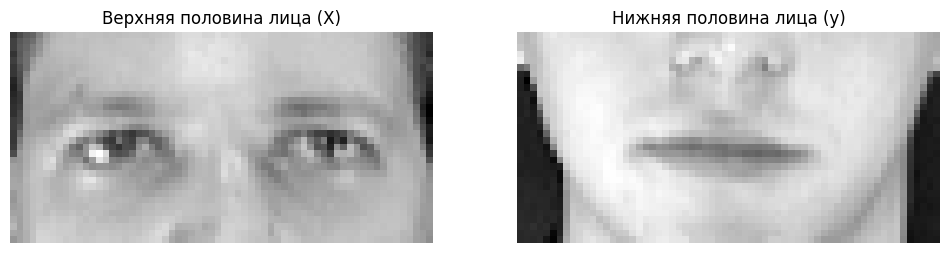

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 2048), (80, 2048))

In [17]:
import time
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgbm
import xgboost as xgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

In [18]:
# GradientBoostingRegressor 23 минуты
start_time = time.time()
gbr = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42), n_jobs = 3)
gbr.fit(X_train, y_train)
t_gbr = time.time() - start_time
p_gbr = gbr.predict(X_test)
r2_gbr = r2_score(y_test, p_gbr)

In [19]:
# XGBoost 15.5 мминут
start_time = time.time() 
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
bst_xgb = xgb.train({'objective': 'reg:squarederror', 'eta': 0.1, 'max_depth': 3}, dtrain, 100) # "nthread": -1 даёт ухудшение по скорости
t_xgb = time.time() - start_time
p_xgb = bst_xgb.predict(dtest)
r2_xgb = r2_score(y_test, p_xgb)

In [20]:
# LightGBM 3 минуты
start_time = time.time()
lgb = MultiOutputRegressor(
    lgbm.LGBMRegressor(objective='regression', learning_rate=0.1, num_leaves=31, n_estimators=10, verbose=-1, random_state=42, n_jobs = -1)
)
lgb.fit(X_train, y_train)
t_lgb = time.time() - start_time
y_pred_lgb = lgb.predict(X_test)
r2_lgb = r2_score(y_test, y_pred_lgb, multioutput='uniform_average')

In [21]:
# CatBoost 3 минуты
start_time = time.time()
cb = MultiOutputRegressor(
    CatBoostRegressor(iterations=10, learning_rate=0.1, depth=3, verbose=0, random_state=42), n_jobs = 3
)
cb.fit(X_train, y_train)
t_cb = time.time() - start_time
y_pred_cb = cb.predict(X_test)
r2_cb = r2_score(y_test, y_pred_cb, multioutput='uniform_average')

In [22]:
print(f'GradientBoosting R2: {r2_gbr:.4f}, Time: {t_gbr:.2f}')
print(f'XGBoost R2: {r2_xgb:.4f}, Time: {t_xgb:.2f}')
print(f'LightGBM R2: {r2_lgb:.4f}, Time: {t_lgb:.2f}')
print(f'CatBoost R2: {r2_cb:.4f}, Time: {t_cb:.2f}')

GradientBoosting R2: 0.4153, Time: 472.66
XGBoost R2: 0.5815, Time: 1033.01
LightGBM R2: 0.4448, Time: 157.19
CatBoost R2: 0.3190, Time: 196.87


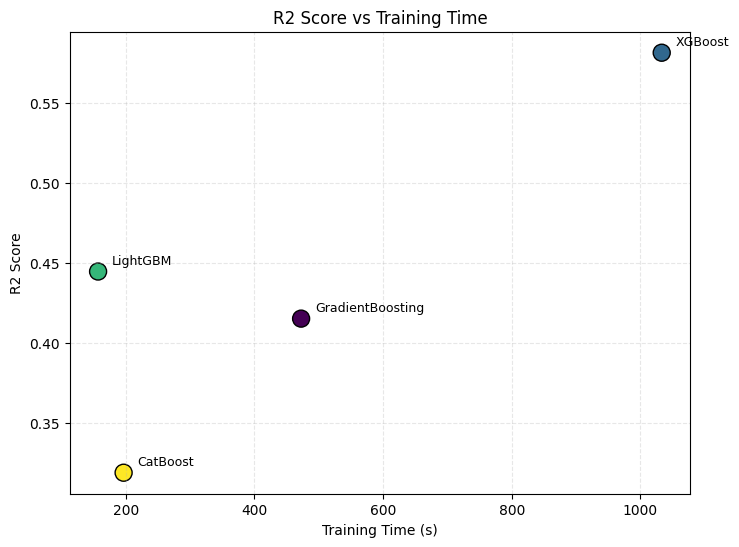

In [23]:
models = ['GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
r2s = [r2_gbr, r2_xgb, r2_lgb, r2_cb]
times = [t_gbr, t_xgb, t_lgb, t_cb]

plt.figure(figsize=(8, 6))
plt.scatter(times, r2s, s=150, c=range(4), cmap='viridis', edgecolors='black')
for i, (m, t, r) in enumerate(zip(models, times, r2s)):
    plt.annotate(m, (t, r), textcoords="offset points", xytext=(10,5), fontsize=9)
plt.xlabel('Training Time (s)')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Training Time')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

XGBoost покзывавет лучшие реульзаты. Следом за ним идёт LightGBM, чьё время выполнение сильно меньше, но и r2 хуже. В остальных 2-ух в данной задаче смысла нет, так как они хуже 2-ух предыдущех и выполняются дольше

## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

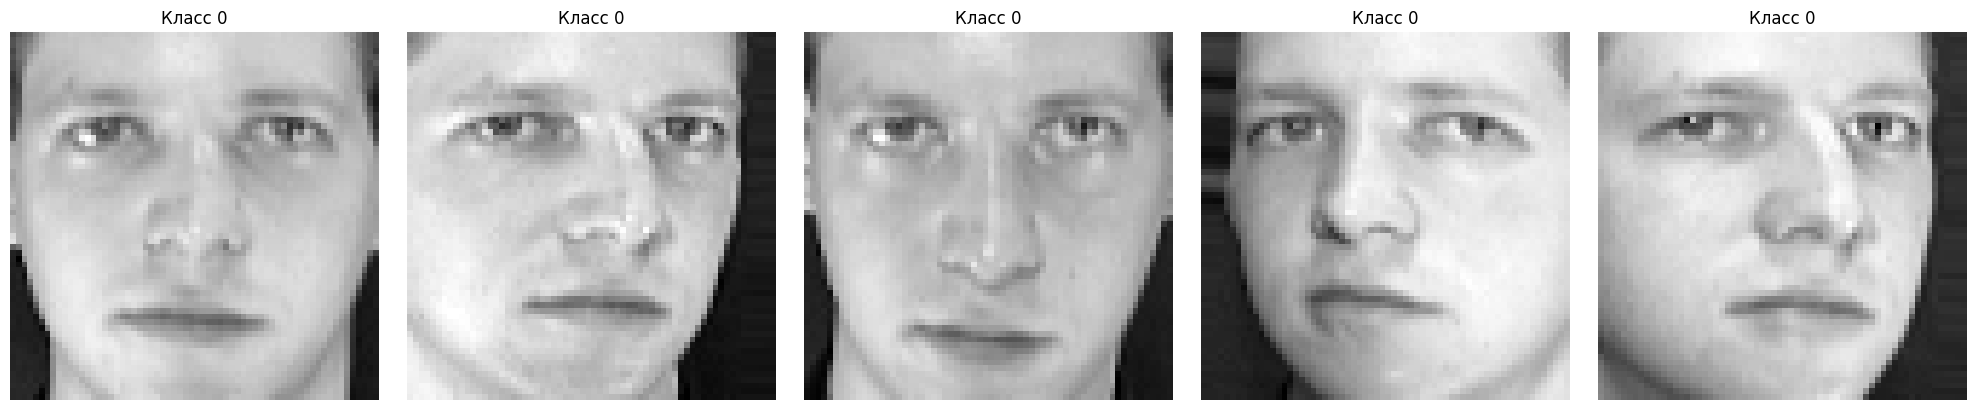

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Импортируём ВСО
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [26]:
X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42 , n_jobs = 3)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs = 3)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

In [28]:
# Создаем ансамбль с мягким голосованием и обучиваем его
voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [29]:
# Теперь обучим каждую модель
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [30]:
# Логистическая регрессия
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy of LR: {acc_lr:.4f}')

# KNN
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy of KNN: {acc_knn:.4f}')

# Дерево решений
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy of DT: {acc_dt:.4f}')

# Наивный Байес
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy of NB: {acc_nb:.4f}')

Accuracy of LR: 0.9625
Accuracy of KNN: 0.8625
Accuracy of DT: 0.4875
Accuracy of NB: 0.8375


In [31]:
# Оценка ансамбля
y_pred_ensemble = voting_clf.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Точность Ансамбля с голосованием: {acc_ensemble:.4f}')

Точность Ансамбля с голосованием: 0.9625


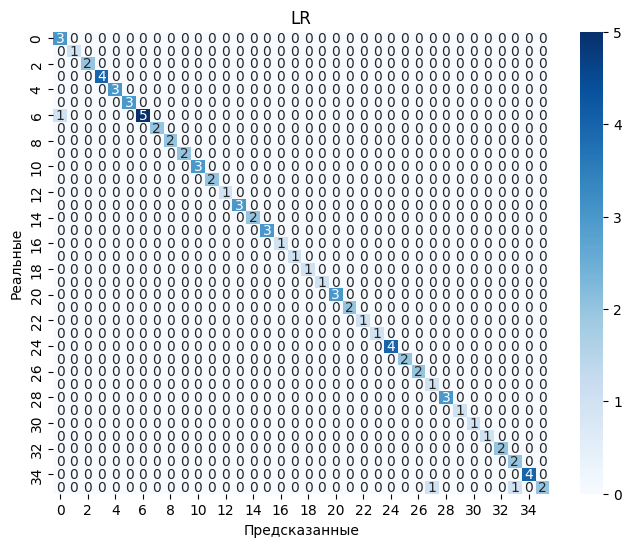

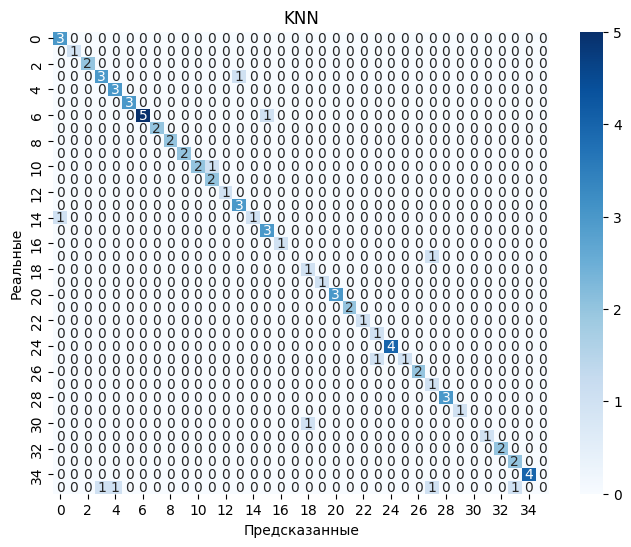

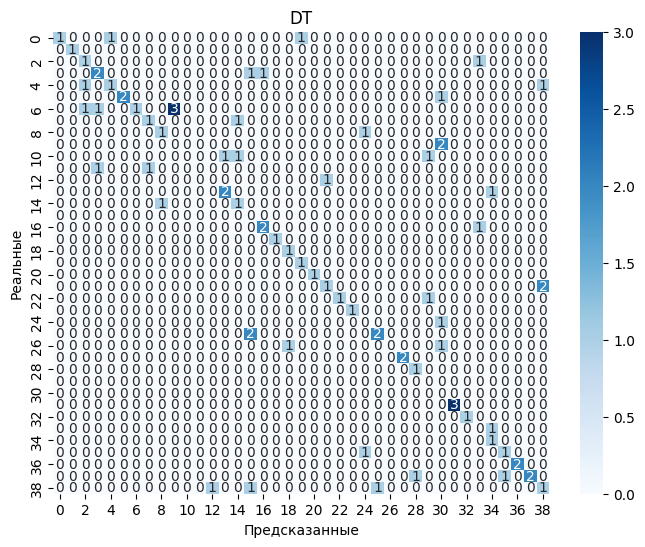

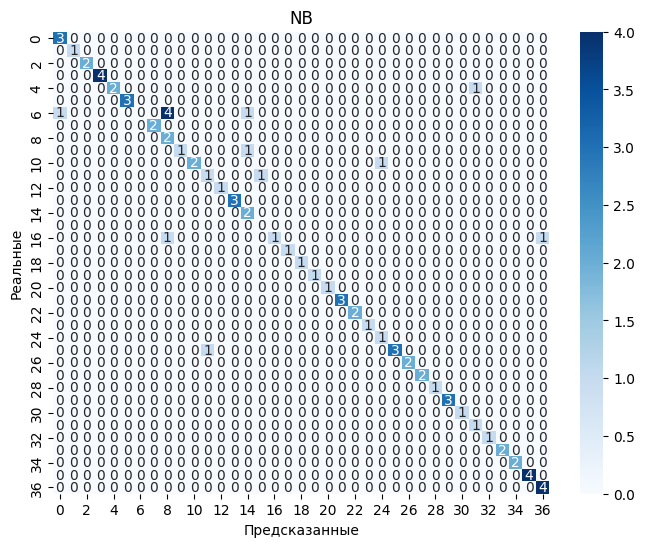

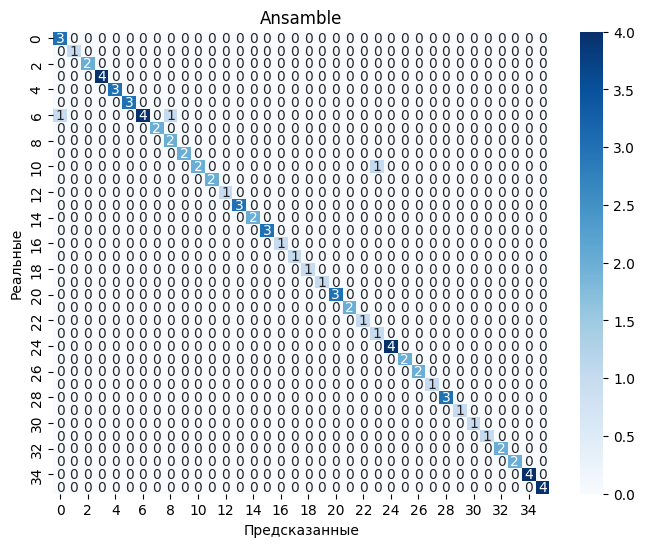

In [32]:
conf_matr(y_test, y_pred_lr, "LR")
conf_matr(y_test, y_pred_knn, "KNN")
conf_matr(y_test, y_pred_dt, "DT")
conf_matr(y_test, y_pred_nb, "NB")
conf_matr(y_test, y_pred_ensemble, "Ansamble")

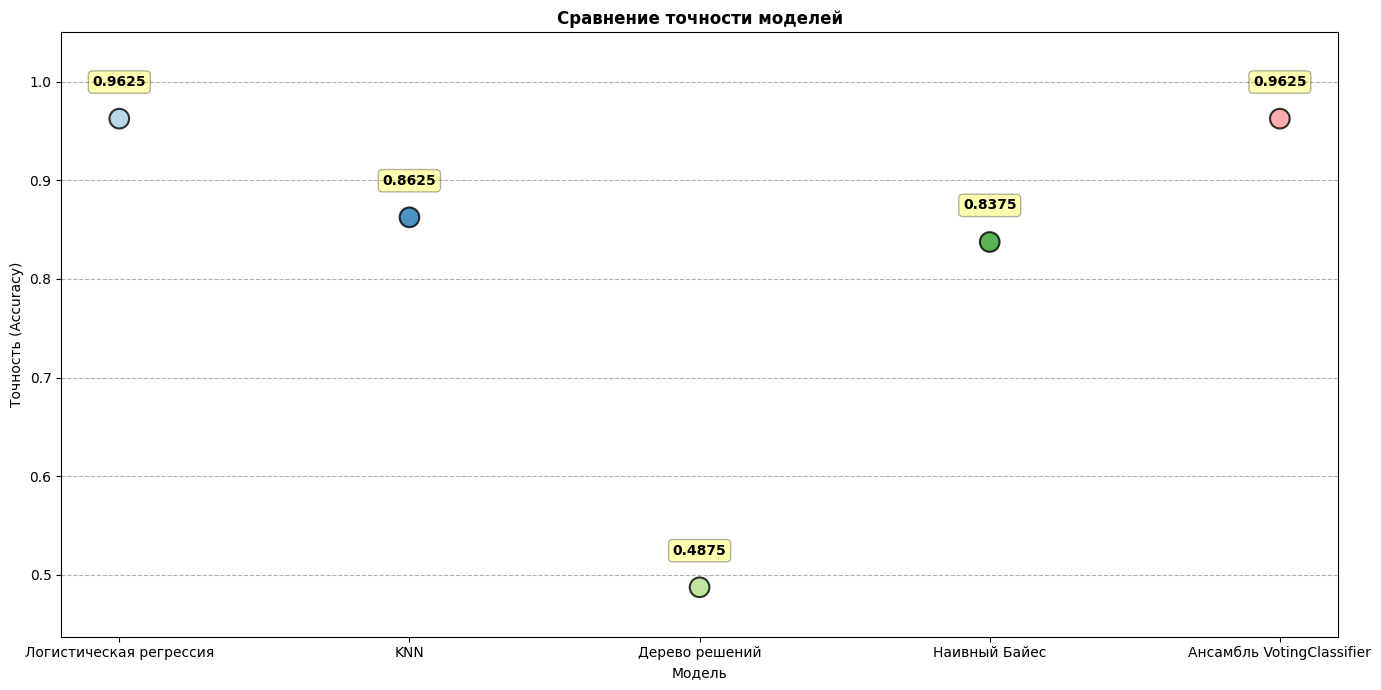

In [33]:
models = ['Логистическая регрессия', 'KNN', 'Дерево решений', 'Наивный Байес', 'Ансамбль VotingClassifier']
accuracies = [acc_lr, acc_knn, acc_dt, acc_nb, acc_ensemble]

plt.figure(figsize=(14, 7))

x_pos = range(len(models))
colors = plt.cm.Paired(range(len(models)))

plt.scatter(x_pos, accuracies, s=200, c=colors, alpha=0.8, edgecolors='black', linewidth=1.5)

plt.xticks(x_pos, models)

plt.title('Сравнение точности моделей', fontweight='bold')
plt.ylabel('Точность (Accuracy)')
plt.xlabel('Модель')

plt.grid(axis='y', linestyle='--')
plt.ylim(min(accuracies) - 0.05, 1.05)

for x, y, model in zip(x_pos, accuracies, models):
    plt.text(x, y + 0.03, f'{y:.4f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

Здесь логистическая регрессия оказалась на равне с ансамблем. Но так как ансамбль учился в частности на лог. регрессии, то можно сделать вывод, что линейная регрессия оказалась лучше.

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

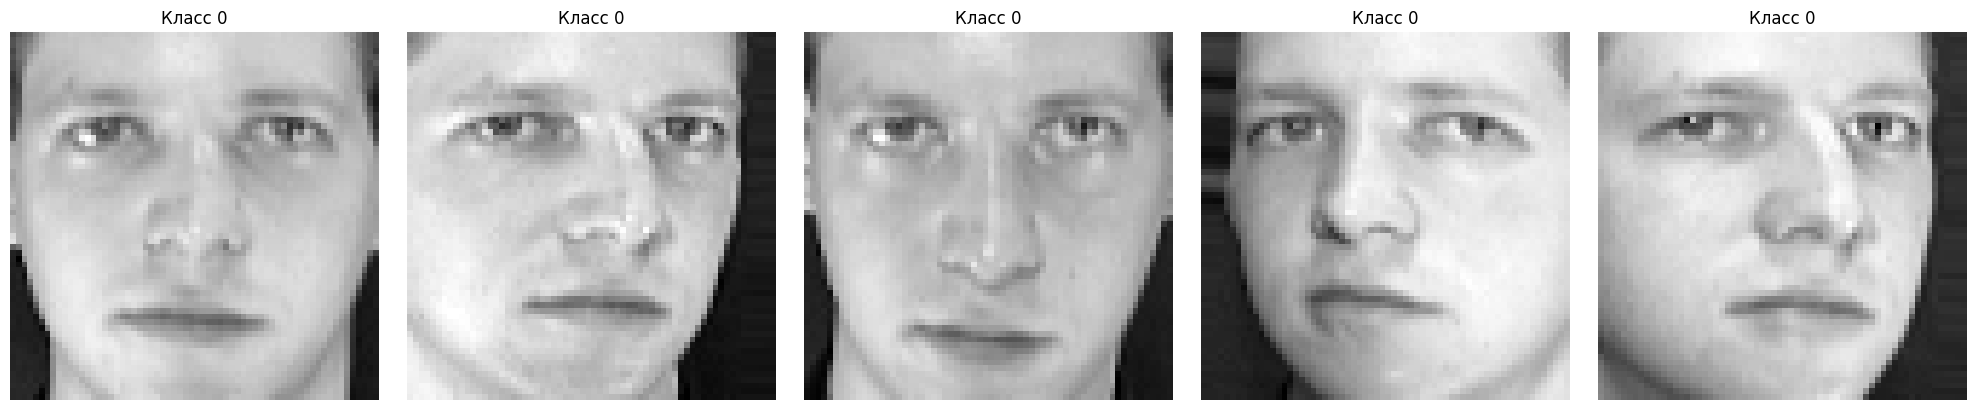

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [35]:
#Ещо раз импортируем ВСО
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, accuracy_score

In [36]:
X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [37]:
lr = LogisticRegression(max_iter=100, random_state=42, n_jobs = 3)
knn = KNeighborsClassifier(n_neighbors=5 , n_jobs = 3)
dt = DecisionTreeClassifier(random_state=42)
nb = GaussianNB()

# Создание регрессора стекинга
stacking_regressor = StackingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('dt', dt), ('nb', nb)],
    final_estimator=LogisticRegression(max_iter=100, random_state=42),
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)

In [38]:
# Обучим
stacking_regressor.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",KFold(n_split... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprec

In [39]:
# Оценка производительности классификатора стекинга
stacking_pred = stacking_regressor.predict(X_test)
acc_stacking = accuracy_score(y_test, stacking_pred)
print(f"Accuracy (Stacking): {acc_stacking:.4f}")
print(classification_report(y_test, stacking_pred))

Accuracy (Stacking): 0.9375
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.00         0
          17       1.00      1.00      1.00         3

In [40]:
models = []
accuracies = []

# Оценка производительности базовых моделей
for name, model in [('LogisticRegression', lr), ('KNeighborsClassifier', knn), ('DecisionTreeClassifier', dt), ('GaussianNB', nb)]:
    # Обучение на всей обучающей выборке
    model.fit(X_train, y_train)
    # Предсказания на тестовых данных
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    models.append(name)
    accuracies.append(acc)
    print(f"Accuracy ({name}): {acc:.4f}")
    print(classification_report(y_test, y_pred))

Accuracy (LogisticRegression): 0.9625
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      1.00

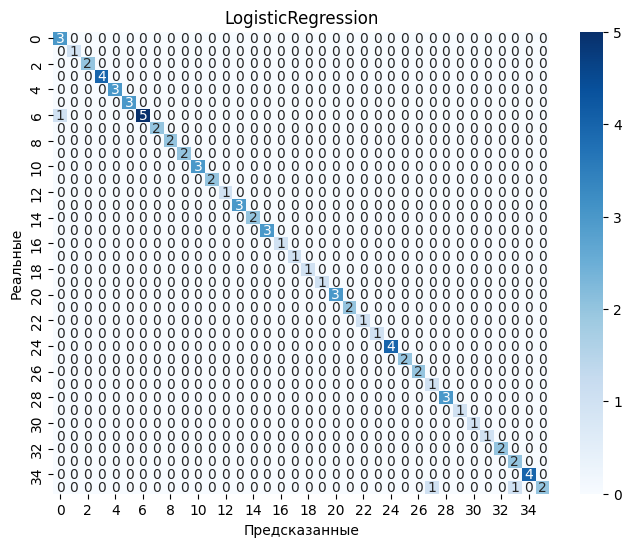

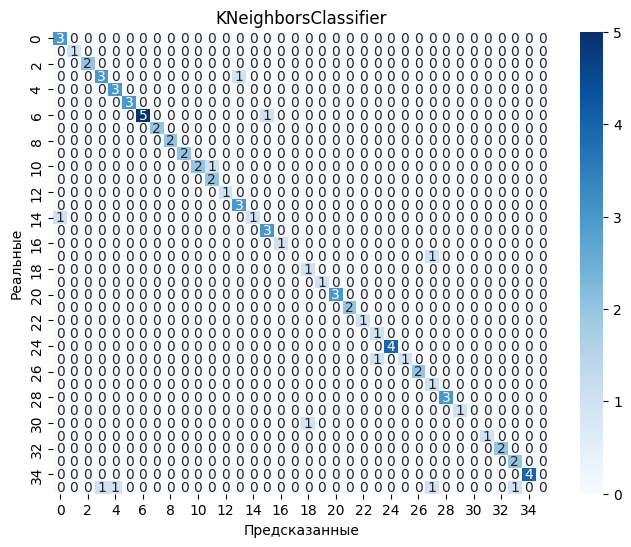

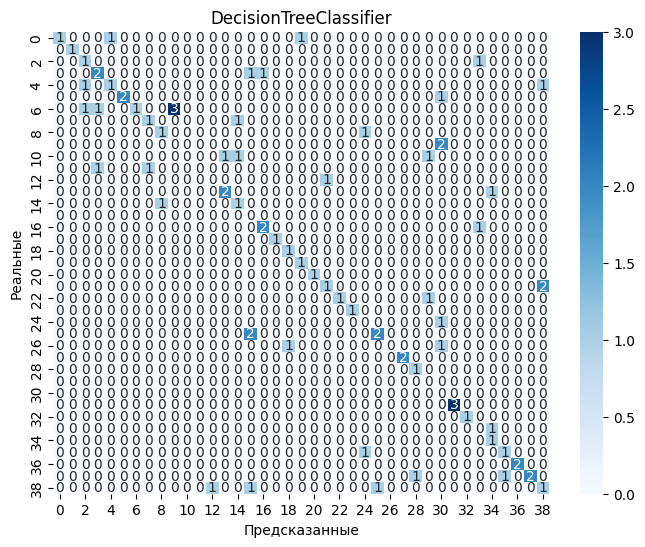

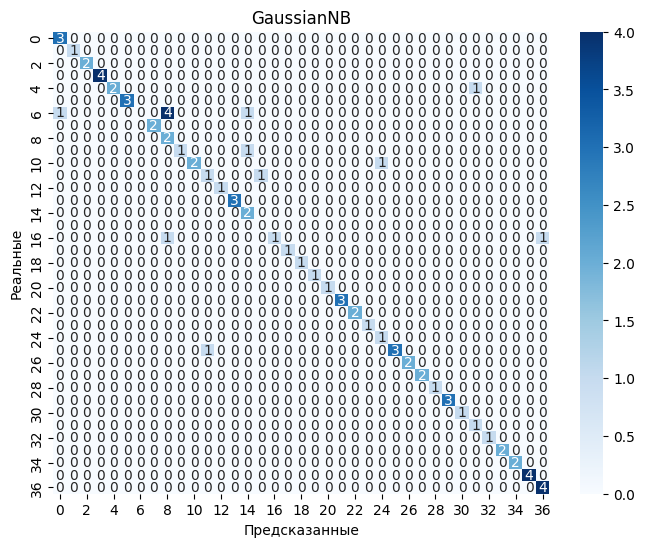

In [41]:
for name, model in [('LogisticRegression', lr), ('KNeighborsClassifier', knn), ('DecisionTreeClassifier', dt), ('GaussianNB', nb)]:
    y_pred = model.predict(X_test)
    conf_matr(y_test, y_pred, name)

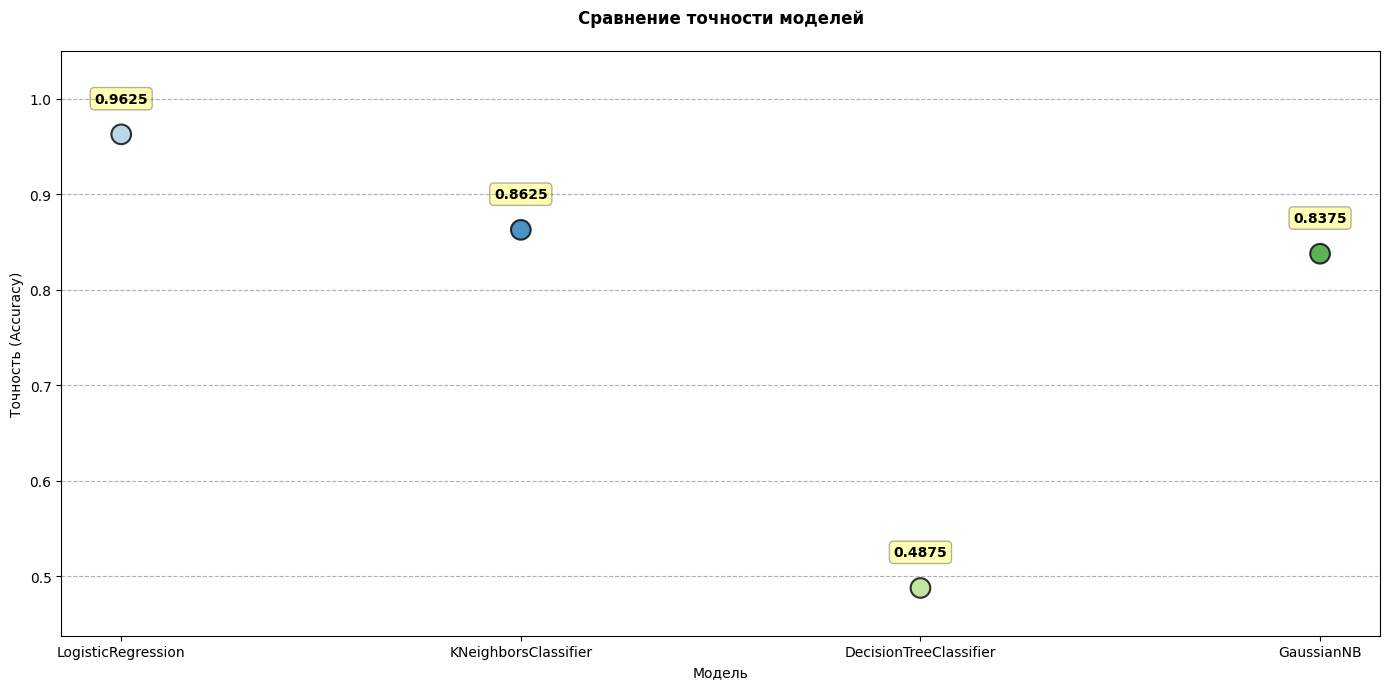

In [42]:
plt.figure(figsize=(14, 7))

x_pos = range(len(models))
colors = plt.cm.Paired(range(len(models)))

plt.scatter(x_pos, accuracies, s=200, c=colors, alpha=0.8, edgecolors='black', linewidth=1.5)

plt.xticks(x_pos, models)

plt.title('Сравнение точности моделей', fontweight='bold', pad=20)
plt.ylabel('Точность (Accuracy)')
plt.xlabel('Модель')

plt.grid(axis='y', linestyle='--')
plt.ylim(min(accuracies) - 0.05, 1.05)

for x, y, model in zip(x_pos, accuracies, models):
    plt.text(x, y + 0.03, f'{y:.4f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

LogisticRegression показал себя лучше всего